# Regularization — Ridge, Lasso & ElasticNet

## The Problem We're Solving

We trained a linear regression model.
It gets **R² = 0.97 on training data** but **R² = 0.53 on test data**.

That massive gap has a name: **overfitting**.
The model memorized the training data — noise and all — instead of learning the actual pattern.

**Regularization is the fix.** It adds a penalty to the loss function that says:
> *"Keep our weights small. Don't chase every wiggle in the training data."*

---


## What We'll Cover

| Section | Topic |
|---------|-------|
| 1 | Why overfitting happens — the real problem |
| 2 | Ridge (L2) — shrink everything |
| 3 | Lasso (L1) — zero out the useless stuff |
| 4 | ElasticNet — best of both |
| 5 | Choosing λ with Cross-Validation |
| 6 | Feature Scaling — the step everyone forgets |
| 7 | Real Dataset — House Prices (Kaggle) |

---

## Dataset

**House Prices — Advanced Regression Techniques**  
Kaggle's most popular regression competition.

Download from: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data  
Save `train.csv` to your `/datasets/` folder.

```python
df = pd.read_csv('/datasets/house_prices_train.csv')
```


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 10

print("All libraries loaded ✓")


All libraries loaded ✓


---
## Section 1 — Why Overfitting Happens

### The Setup

Imagine we have a dataset with **100 features** but only **50 training samples**.
More features than samples = a recipe for disaster.

The model has so much freedom that it can perfectly fit every single training point —
including the random noise in the data.

But noise is random. On new data, that noise looks different.
So the model's "perfect" fit becomes terrible predictions.

### What causes huge weights?

When a model overfits, it learns **enormous weights** on noisy features.
Example:
```
feature_42 = 0.003  (weak real signal)
weight_42  = +8,400  (model inflated it to chase training noise)
```

On training data: that giant weight happens to be right.
On test data: it's catastrophically wrong.

**Regularization prevents this by penalizing large weights.**


  Plain Linear Regression — No Regularization
  Train R²  :  0.9852   ← suspiciously high
  Test  R²  :  -1.0314   ← much worse
  Gap       :  2.0166   ← this is the overfitting gap

  Learned weights (first 10 features):
     Feature    True w   Learned w    Difference
  ------------------------------------------------
  feat_00         3.00        3.15         +0.15  ← real signal
  feat_01        -2.50       -2.76         -0.26  ← real signal
  feat_02         1.80        2.72         +0.92  ← real signal
  feat_03        -1.20       -2.82         -1.62  ← real signal
  feat_04         2.10        2.12         +0.02  ← real signal
  feat_05         0.00       -2.01         -2.01  ← should be 0!
  feat_06         0.00       -1.87         -1.87  ← should be 0!
  feat_07         0.00       -1.03         -1.03  ← should be 0!
  feat_08         0.00        1.84         +1.84  ← should be 0!
  feat_09         0.00        0.82         +0.82  ← should be 0!

  Max |weight| on noise features

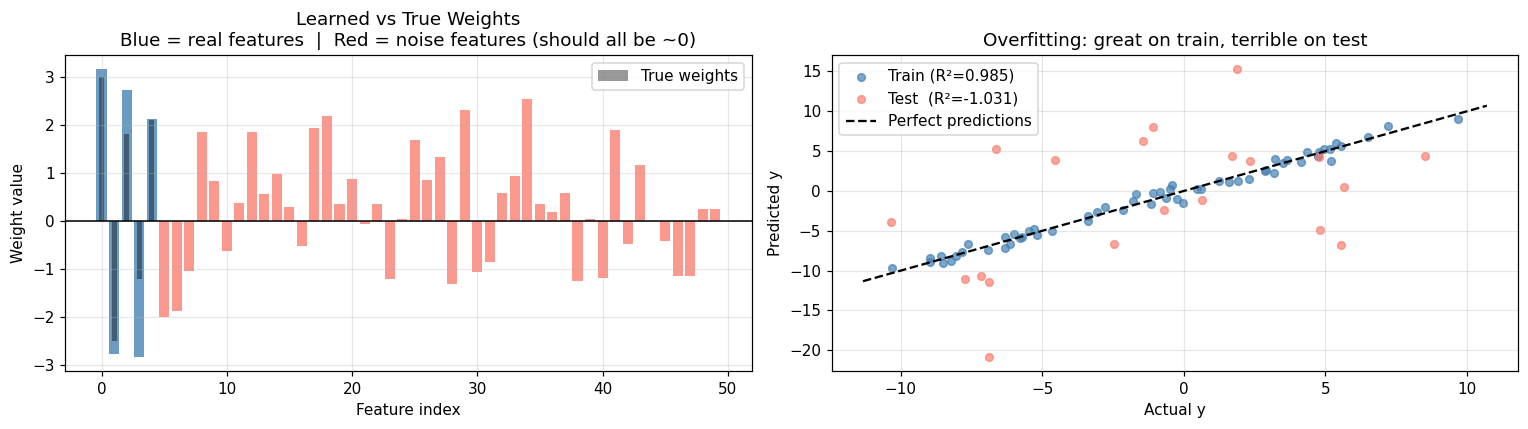

In [42]:
# ── Demonstrate overfitting with too many features ────────────────────────────

np.random.seed(0)

n_samples  = 80          # small dataset
n_real     = 5           # only 5 features have real signal
n_noise    = 45          # 45 features are pure noise
n_features = n_real + n_noise

# Create data: only the first 5 features matter
X = np.random.randn(n_samples, n_features)

# True weights: first 5 are meaningful, rest are exactly 0
true_weights = np.zeros(n_features)
true_weights[:5] = [3.0, -2.5, 1.8, -1.2, 2.1]

y = X @ true_weights + np.random.randn(n_samples) * 2.0   # small noise

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ── Fit plain linear regression (no regularization) ───────────────────────────
plain = LinearRegression()
plain.fit(X_train, y_train)

r2_train = r2_score(y_train, plain.predict(X_train))
r2_test  = r2_score(y_test,  plain.predict(X_test))

print("=" * 55)
print("  Plain Linear Regression — No Regularization")
print("=" * 55)
print(f"  Train R²  :  {r2_train:.4f}   ← suspiciously high")
print(f"  Test  R²  :  {r2_test:.4f}   ← much worse")
print(f"  Gap       :  {r2_train - r2_test:.4f}   ← this is the overfitting gap")
print()
print("  Learned weights (first 10 features):")
print(f"  {'Feature':>10}  {'True w':>8}  {'Learned w':>10}  {'Difference':>12}")
print("  " + "-" * 48)
for i in range(10):
    diff = plain.coef_[i] - true_weights[i]
    note = "← real signal" if i < 5 else "← should be 0!"
    print(f"  feat_{i:02d}     {true_weights[i]:>8.2f}  {plain.coef_[i]:>10.2f}  {diff:>+12.2f}  {note}")

print(f"\n  Max |weight| on noise features: {np.max(np.abs(plain.coef_[5:])):.2f}")
print("  These are enormous weights on features that should be 0!")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Weight comparison
colors = ['steelblue' if i < 5 else 'salmon' for i in range(n_features)]
axes[0].bar(range(n_features), plain.coef_, color=colors, alpha=0.8, width=0.8)
axes[0].bar(range(n_features), true_weights, color='black', alpha=0.4, width=0.4, label='True weights')
axes[0].axhline(0, color='k', linewidth=1)
axes[0].set_xlabel('Feature index')
axes[0].set_ylabel('Weight value')
axes[0].set_title('Learned vs True Weights\nBlue = real features  |  Red = noise features (should all be ~0)')
axes[0].legend()

# Actual vs predicted: train vs test
axes[1].scatter(y_train, plain.predict(X_train), s=25, alpha=0.7,
                color='steelblue', label=f'Train (R²={r2_train:.3f})')
axes[1].scatter(y_test,  plain.predict(X_test),  s=25, alpha=0.7,
                color='salmon',    label=f'Test  (R²={r2_test:.3f})')
all_y = np.concatenate([y_train, y_test])
lim = [all_y.min() - 1, all_y.max() + 1]
axes[1].plot(lim, lim, 'k--', lw=1.5, label='Perfect predictions')
axes[1].set_xlabel('Actual y')
axes[1].set_ylabel('Predicted y')
axes[1].set_title('Overfitting: great on train, terrible on test')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## Section 2 — Ridge Regression (L2 Regularization)

### The Formula

$$\text{Ridge Loss} = \underbrace{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{MSE — fit the data}} + \underbrace{\lambda \sum_{j=1}^{p} w_j^2}_{\text{L2 penalty — keep weights small}}$$

The model has to **balance two goals at once**:
1. Minimize prediction error (fit the data well)
2. Minimize weight magnitude (stay simple)

`λ` (lambda, also called `alpha` in sklearn) controls the trade-off:
- `λ = 0` → pure linear regression, no penalty
- `λ → ∞` → all weights forced to zero (model predicts just the mean)

---

### The Intuition

Think of λ as friction on the weights.
Without friction, weights can grow as large as they want to chase noise.
With friction, the optimizer thinks twice before making a weight large — it has to be *worth it*.

---

### Key Property: Ridge Shrinks All Weights Proportionally

Ridge **never** drives a weight exactly to zero.
It shrinks everything — useful features and noisy features — toward zero.
If a feature is truly useless, Ridge makes its weight very small but not zero.

**When to use Ridge:**
- Most of our features probably matter
- We're dealing with multicollinearity (features are correlated with each other)
- We want stable, consistent predictions


  Ridge at Different λ Values
         λ    Train R²    Test R²    Max |weight|   # near-zero
  ------------------------------------------------------------
     0.001      0.9852    -1.0270           3.150             4 ← best test
       0.1      0.9847    -0.6697           3.162             4 ← best test
       1.0      0.9736     0.2851           3.069             8 ← best test
      10.0      0.9192     0.5973           2.257            13 ← best test
     100.0      0.6200     0.3188           0.946            14
    1000.0      0.1428     0.0616           0.165            47

  Notice: as λ increases →
    Train R² goes DOWN  (we're constraining the model more)
    Test  R² goes UP    (less overfitting) ... then DOWN (too much constraint)
    Max weight shrinks  (regularization is working)
    # near-zero grows  (but NEVER exact zero — that's Ridge's limitation)


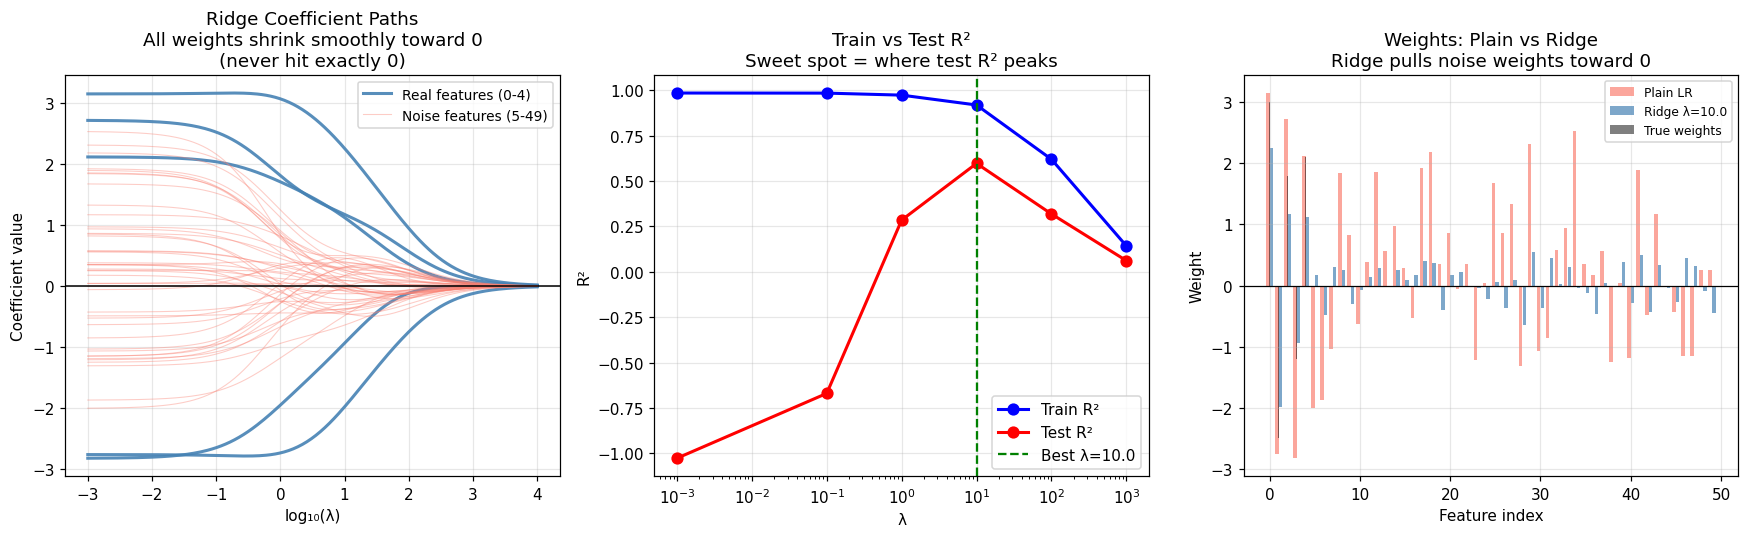

In [43]:
# ── Ridge regression at different λ values ────────────────────────────────────

# Using the same overfitting dataset from Section 1
lambdas = [0.001, 0.1, 1.0, 10.0, 100.0, 1000.0]

print("=" * 65)
print("  Ridge at Different λ Values")
print("=" * 65)
print(f"  {'λ':>8}  {'Train R²':>10}  {'Test R²':>9}  {'Max |weight|':>14}  {'# near-zero':>12}")
print("  " + "-" * 60)

ridge_results = []
for lam in lambdas:
    m = Ridge(alpha=lam)
    m.fit(X_train, y_train)
    r2_tr = r2_score(y_train, m.predict(X_train))
    r2_te = r2_score(y_test,  m.predict(X_test))
    max_w = np.max(np.abs(m.coef_))
    near_zero = np.sum(np.abs(m.coef_) < 0.1)
    ridge_results.append({'lam': lam, 'r2_tr': r2_tr, 'r2_te': r2_te,
                           'max_w': max_w, 'coef': m.coef_.copy()})
    flag = " ← best test" if r2_te == max(r['r2_te'] for r in ridge_results) else ""
    print(f"  {lam:>8}  {r2_tr:>10.4f}  {r2_te:>9.4f}  {max_w:>14.3f}  {near_zero:>12}{flag}")

print()
print("  Notice: as λ increases →")
print("    Train R² goes DOWN  (we're constraining the model more)")
print("    Test  R² goes UP    (less overfitting) ... then DOWN (too much constraint)")
print("    Max weight shrinks  (regularization is working)")
print("    # near-zero grows  (but NEVER exact zero — that's Ridge's limitation)")

# ── Coefficient paths as λ changes ────────────────────────────────────────────
lam_range = np.logspace(-3, 4, 200)
coef_path = np.zeros((len(lam_range), n_features))
for i, lam in enumerate(lam_range):
    m = Ridge(alpha=lam)
    m.fit(X_train, y_train)
    coef_path[i] = m.coef_

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Coefficient paths
for j in range(n_features):
    color = 'steelblue' if j < 5 else 'salmon'
    lw    = 2.0 if j < 5 else 0.7
    alpha = 0.9 if j < 5 else 0.4
    label = 'Real features (0-4)' if j == 0 else ('Noise features (5-49)' if j == 5 else None)
    axes[0].plot(np.log10(lam_range), coef_path[:, j],
                 color=color, lw=lw, alpha=alpha, label=label)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_xlabel('log₁₀(λ)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Ridge Coefficient Paths\nAll weights shrink smoothly toward 0\n(never hit exactly 0)')
axes[0].legend(fontsize=9)

# Train vs Test R² curve
lam_plot  = [r['lam'] for r in ridge_results]
r2_trains = [r['r2_tr'] for r in ridge_results]
r2_tests  = [r['r2_te'] for r in ridge_results]
best_lam  = lam_plot[np.argmax(r2_tests)]
axes[1].semilogx(lam_plot, r2_trains, 'b-o', lw=2, ms=7, label='Train R²')
axes[1].semilogx(lam_plot, r2_tests,  'r-o', lw=2, ms=7, label='Test R²')
axes[1].axvline(best_lam, color='green', ls='--', lw=1.5, label=f'Best λ={best_lam}')
axes[1].set_xlabel('λ')
axes[1].set_ylabel('R²')
axes[1].set_title('Train vs Test R²\nSweet spot = where test R² peaks')
axes[1].legend()

# Best Ridge vs Plain weights comparison
best_ridge_coef = ridge_results[np.argmax(r2_tests)]['coef']
x_pos = np.arange(n_features)
axes[2].bar(x_pos - 0.2, plain.coef_,      0.38, label='Plain LR',   color='salmon',    alpha=0.7)
axes[2].bar(x_pos + 0.2, best_ridge_coef,  0.38, label=f'Ridge λ={best_lam}', color='steelblue', alpha=0.7)
axes[2].bar(x_pos,       true_weights,     0.1,  label='True weights', color='black',    alpha=0.5)
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_xlabel('Feature index')
axes[2].set_ylabel('Weight')
axes[2].set_title('Weights: Plain vs Ridge\nRidge pulls noise weights toward 0')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Section 3 — Lasso Regression (L1 Regularization)

### The Formula

$$\text{Lasso Loss} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |w_j|$$

The only difference from Ridge: we use **absolute values** `|w|` instead of squares `w²`.
That one change has a dramatic consequence.

---

### The Key Difference: Lasso Creates Exact Zeros

Ridge shrinks weights — but they stay non-zero.
Lasso drives some weights to **exactly 0.0**.

This means Lasso does **automatic feature selection**:
- Features with weight = 0 are completely ignored
- Only truly important features survive

---

### Why Does L1 Create Zeros But L2 Doesn't?

No proof needed — here's the intuition:

> **Ridge (L2):** The penalty `w²` has a gentle slope near zero.
> Shrinking a small weight from 0.01 → 0.00 saves almost nothing: `0.01² - 0² = 0.0001`.
> So the optimizer leaves small weights alive.

> **Lasso (L1):** The penalty `|w|` has a **constant slope** everywhere.
> Shrinking 0.01 → 0.00 saves exactly 0.01 × λ — the same saving as going from 1.0 → 0.99.
> So the optimizer aggressively kills weights all the way to zero.

---

### When to Use Lasso

- We have **many features** and suspect most are irrelevant
- We want an **interpretable model** (fewer active features)
- We want the model to tell we *which* features matter


  Lasso at Different λ Values
         λ    Train R²    Test R²    Non-zero w    Correct 5 kept
  -----------------------------------------------------------------
     0.001      0.9851    -0.8459            50  5/5 real features ← best
      0.01      0.9768     0.1912            48  5/5 real features ← best
      0.05      0.9516     0.7752            37  5/5 real features ← best
       0.1      0.9290     0.8366            27  5/5 real features ← best
       0.3      0.8603     0.8798            15  5/5 real features ← best
       0.5      0.7838     0.8198             9  5/5 real features
       1.0      0.5974     0.5728             4  4/5 real features

  See how Lasso progressively zeros out features as λ grows!
  At the right λ, it can recover exactly the 5 real features.


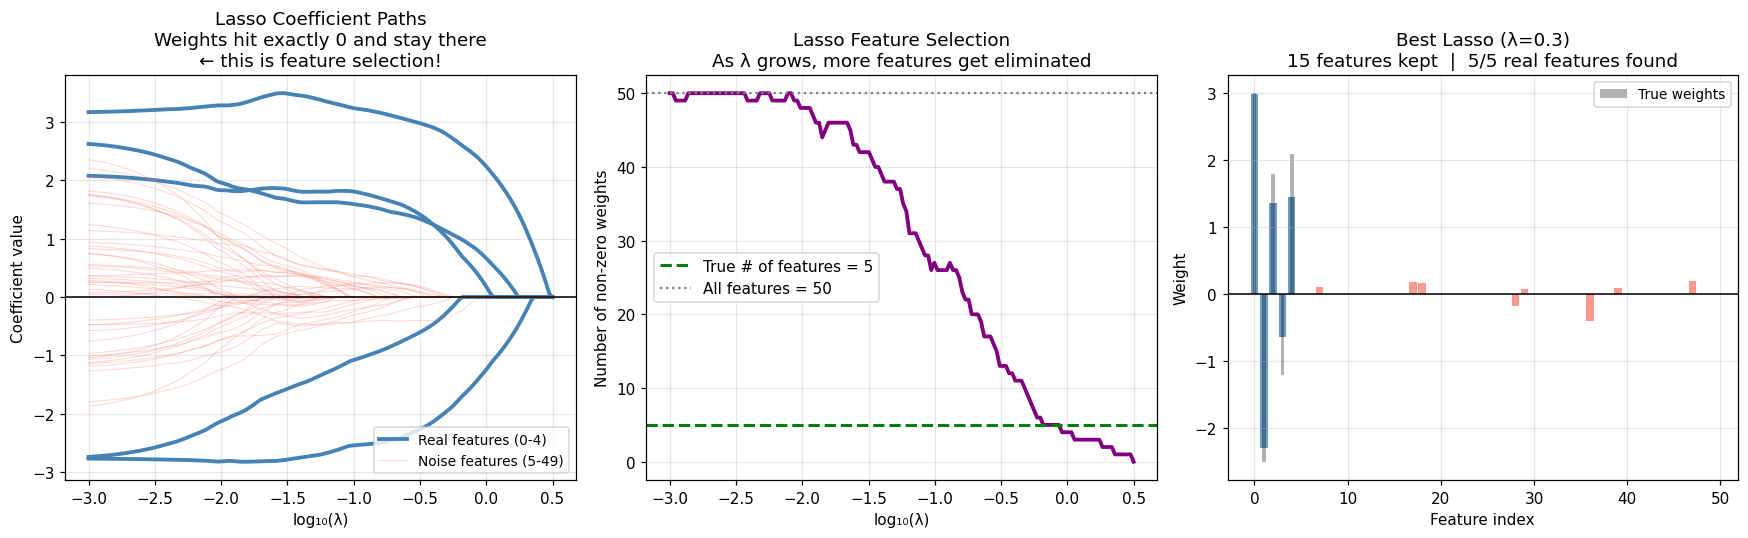

In [44]:
# ── Lasso: watch features get zeroed out ─────────────────────────────────────

lasso_lambdas = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0]

print("=" * 70)
print("  Lasso at Different λ Values")
print("=" * 70)
print(f"  {'λ':>8}  {'Train R²':>10}  {'Test R²':>9}  {'Non-zero w':>12}  {'Correct 5 kept':>16}")
print("  " + "-" * 65)

lasso_results = []
for lam in lasso_lambdas:
    m = Lasso(alpha=lam, max_iter=10000)
    m.fit(X_train, y_train)
    r2_tr    = r2_score(y_train, m.predict(X_train))
    r2_te    = r2_score(y_test,  m.predict(X_test))
    n_nonzero = np.sum(m.coef_ != 0)
    n_correct = np.sum(m.coef_[:5] != 0)   # how many of the 5 real features survived
    lasso_results.append({'lam': lam, 'r2_tr': r2_tr, 'r2_te': r2_te,
                           'n_nonzero': n_nonzero, 'coef': m.coef_.copy()})
    flag = " ← best" if r2_te == max(r['r2_te'] for r in lasso_results) else ""
    print(f"  {lam:>8}  {r2_tr:>10.4f}  {r2_te:>9.4f}  {n_nonzero:>12}  {n_correct}/5 real features{flag}")

print()
print("  See how Lasso progressively zeros out features as λ grows!")
print("  At the right λ, it can recover exactly the 5 real features.")

# ── Coefficient paths ─────────────────────────────────────────────────────────
lam_range_l = np.logspace(-3, 0.5, 150)
coef_path_l = np.zeros((len(lam_range_l), n_features))
for i, lam in enumerate(lam_range_l):
    m = Lasso(alpha=lam, max_iter=10000)
    m.fit(X_train, y_train)
    coef_path_l[i] = m.coef_

n_nonzero_path = (coef_path_l != 0).sum(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Coefficient paths — Lasso
for j in range(n_features):
    color = 'steelblue' if j < 5 else 'salmon'
    lw    = 2.5 if j < 5 else 0.7
    alpha = 1.0 if j < 5 else 0.3
    label = 'Real features (0-4)' if j == 0 else ('Noise features (5-49)' if j == 5 else None)
    axes[0].plot(np.log10(lam_range_l), coef_path_l[:, j],
                 color=color, lw=lw, alpha=alpha, label=label)
axes[0].axhline(0, color='k', lw=1)
axes[0].set_xlabel('log₁₀(λ)')
axes[0].set_ylabel('Coefficient value')
axes[0].set_title('Lasso Coefficient Paths\nWeights hit exactly 0 and stay there\n← this is feature selection!')
axes[0].legend(fontsize=9)

# Sparsity: how many weights are nonzero?
axes[1].plot(np.log10(lam_range_l), n_nonzero_path, 'purple', lw=2.5)
axes[1].axhline(5, color='green', ls='--', lw=2, label='True # of features = 5')
axes[1].axhline(n_features, color='gray', ls=':', lw=1.5, label=f'All features = {n_features}')
axes[1].set_xlabel('log₁₀(λ)')
axes[1].set_ylabel('Number of non-zero weights')
axes[1].set_title('Lasso Feature Selection\nAs λ grows, more features get eliminated')
axes[1].legend()

# Best Lasso weights
best_lasso_res = lasso_results[np.argmax([r['r2_te'] for r in lasso_results])]
best_coef_l    = best_lasso_res['coef']
x_pos = np.arange(n_features)
axes[2].bar(x_pos, best_coef_l, color=['steelblue' if i < 5 else 'salmon' for i in range(n_features)],
            alpha=0.8, width=0.8)
axes[2].bar(x_pos, true_weights, color='black', alpha=0.3, width=0.4, label='True weights')
axes[2].axhline(0, color='k', lw=1)
axes[2].set_xlabel('Feature index')
axes[2].set_ylabel('Weight')
axes[2].set_title(f'Best Lasso (λ={best_lasso_res["lam"]})\n'
                  f'{best_lasso_res["n_nonzero"]} features kept  |  '
                  f'{np.sum(best_coef_l[:5] != 0)}/5 real features found')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
### Ridge vs Lasso — Side-by-Side Summary

| | Ridge (L2) | Lasso (L1) |
|---|---|---|
| **Penalty** | `λ Σ wᵢ²` | `λ Σ \|wᵢ\|` |
| **Effect on weights** | Shrinks all toward 0 | Drives some to exactly 0 |
| **Feature selection** | ✗ No — keeps all features | ✓ Yes — automatic |
| **Interpretability** | Moderate (many small weights) | High (sparse weights) |
| **Best for** | Correlated features, most matter | Many irrelevant features |
| **sklearn class** | `Ridge(alpha=λ)` | `Lasso(alpha=λ)` |


---
## Section 4 — ElasticNet — Best of Both Worlds

### The Formula

$$\text{ElasticNet Loss} = MSE + \lambda_1 \sum|w_j| + \lambda_2 \sum w_j^2$$

ElasticNet combines Ridge and Lasso.
In sklearn, We control the mix with one parameter: `l1_ratio`

```python
l1_ratio = 0.0   # pure Ridge
l1_ratio = 0.5   # 50% Lasso + 50% Ridge
l1_ratio = 1.0   # pure Lasso
```

---

### When Does ElasticNet Win?

Lasso has a known weakness: when features are **correlated** with each other, it tends to arbitrarily pick one and zero out the rest — even if both carry signal.

Ridge handles correlated features better (it distributes weight across them).

**ElasticNet gets the best of both:**
- The sparsity (zeros) from Lasso
- The stability with correlated features from Ridge

**Practical rule of thumb:**
When we're unsure whether to use Ridge or Lasso, try ElasticNet with `l1_ratio=0.5` first.


  ElasticNet: Sweeping l1_ratio (α=0.1 fixed)
  0.0 = Ridge, 1.0 = Lasso
    l1_ratio    Train R²    Test R²    Non-zero w
  ------------------------------------------------
         0.0      0.9847    -0.6697            50  ← Ridge
         0.1      0.9402     0.6497            47  
         0.3      0.9397     0.7321            44  
         0.5      0.9375     0.7870            41  
         0.7      0.9336     0.8184            33  
         0.9      0.9301     0.8312            27  
         1.0      0.9290     0.8366            27  ← Lasso


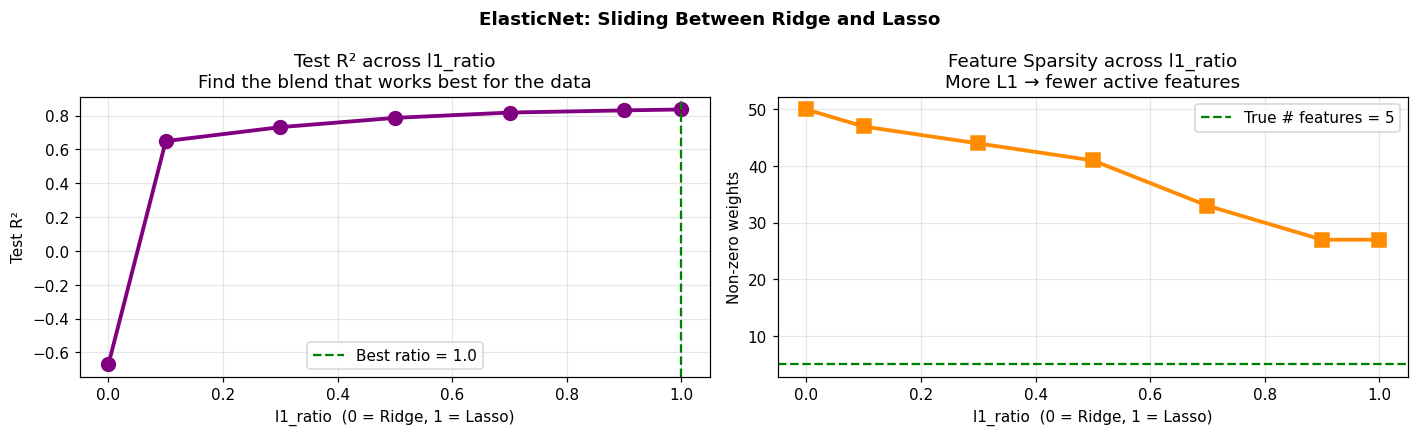

In [45]:
# ── ElasticNet: sweep the l1_ratio from Ridge → Lasso ─────────────────────────

l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]

print("=" * 60)
print("  ElasticNet: Sweeping l1_ratio (α=0.1 fixed)")
print("  0.0 = Ridge, 1.0 = Lasso")
print("=" * 60)
print(f"  {'l1_ratio':>10}  {'Train R²':>10}  {'Test R²':>9}  {'Non-zero w':>12}")
print("  " + "-" * 48)

en_results = []
for ratio in l1_ratios:
    if ratio == 0.0:
        m = Ridge(alpha=0.1)
    elif ratio == 1.0:
        m = Lasso(alpha=0.1, max_iter=10000)
    else:
        m = ElasticNet(alpha=0.1, l1_ratio=ratio, max_iter=10000)
    m.fit(X_train, y_train)
    r2_tr = r2_score(y_train, m.predict(X_train))
    r2_te = r2_score(y_test,  m.predict(X_test))
    nz    = np.sum(m.coef_ != 0) if hasattr(m, 'coef_') else n_features
    en_results.append({'ratio': ratio, 'r2_tr': r2_tr, 'r2_te': r2_te, 'nz': nz})
    label = "← Ridge" if ratio == 0.0 else ("← Lasso" if ratio == 1.0 else "")
    print(f"  {ratio:>10.1f}  {r2_tr:>10.4f}  {r2_te:>9.4f}  {nz:>12}  {label}")

# ── Visualize the sweep ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ratios_p  = [r['ratio'] for r in en_results]
r2_te_p   = [r['r2_te'] for r in en_results]
nz_p      = [r['nz']    for r in en_results]

axes[0].plot(ratios_p, r2_te_p, 'o-', color='purple', lw=2.5, ms=9)
axes[0].axvline(ratios_p[np.argmax(r2_te_p)], color='green', ls='--',
                label=f'Best ratio = {ratios_p[np.argmax(r2_te_p)]}')
axes[0].set_xlabel('l1_ratio  (0 = Ridge, 1 = Lasso)')
axes[0].set_ylabel('Test R²')
axes[0].set_title('Test R² across l1_ratio\nFind the blend that works best for the data')
axes[0].legend()

axes[1].plot(ratios_p, nz_p, 's-', color='darkorange', lw=2.5, ms=9)
axes[1].axhline(5, color='green', ls='--', lw=1.5, label='True # features = 5')
axes[1].set_xlabel('l1_ratio  (0 = Ridge, 1 = Lasso)')
axes[1].set_ylabel('Non-zero weights')
axes[1].set_title('Feature Sparsity across l1_ratio\nMore L1 → fewer active features')
axes[1].legend()

plt.suptitle('ElasticNet: Sliding Between Ridge and Lasso', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 5 — Choosing λ with Cross-Validation

### The Big Question: What Should λ Be?

`λ` is a **hyperparameter** — we choose it, the model doesn't learn it.

**Wrong way:** Pick λ = 1.0 because it sounds reasonable.
**Right way:** Try many values of λ, measure performance on held-out data, pick the best.

This is called **hyperparameter tuning via cross-validation**.

### How Cross-Validation Works

```
All training data
    ↓  Split into 5 folds
Fold 1: [Test] [Train] [Train] [Train] [Train]  → score_1
Fold 2: [Train] [Test] [Train] [Train] [Train]  → score_2
Fold 3: [Train] [Train] [Test] [Train] [Train]  → score_3
Fold 4: [Train] [Train] [Train] [Test] [Train]  → score_4
Fold 5: [Train] [Train] [Train] [Train] [Test]  → score_5

Mean score = (score_1 + ... + score_5) / 5
```

Try this for 50 different values of λ → pick the λ with the best mean score.

**sklearn does this automatically** with `RidgeCV`, `LassoCV`, `ElasticNetCV`.


  Auto CV Results
  RidgeCV         best λ=10.7227  Test R²=0.5945  Non-zero=50
  LassoCV         best λ=0.2984  Test R²=0.8799  Non-zero=15
  ElasticNetCV    best λ=0.2838  Test R²=0.8809  Non-zero=16  l1_ratio=1.0


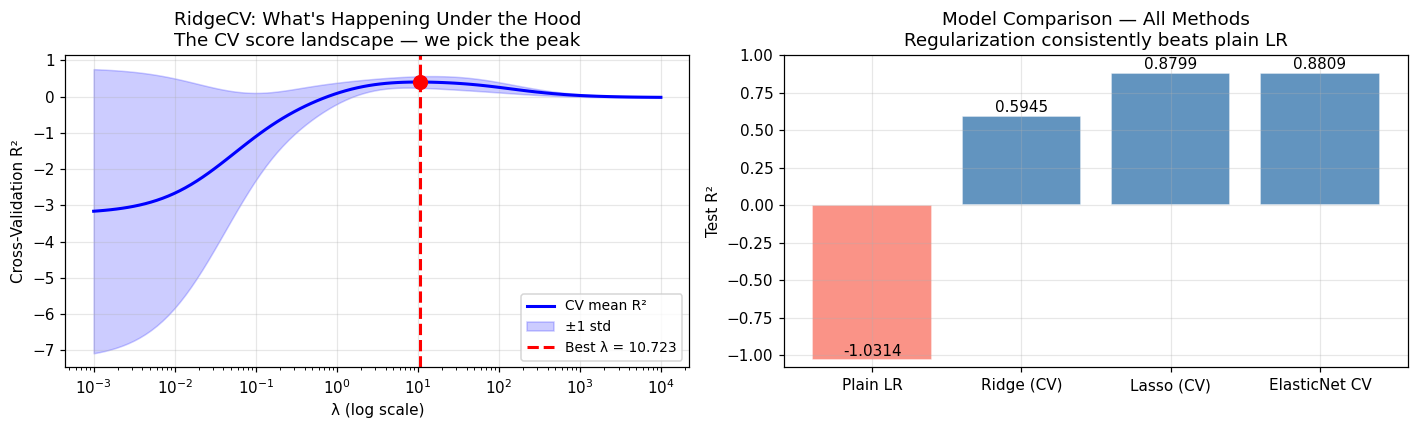

In [46]:
# ── Automatic λ selection with CV classes ─────────────────────────────────────

lam_candidates = np.logspace(-3, 4, 100)   # 100 λ values to try: 0.001 → 10,000

# RidgeCV — tries all lambdas with 5-fold CV internally
ridge_cv = RidgeCV(alphas=lam_candidates, cv=5)
ridge_cv.fit(X_train, y_train)

# LassoCV — same idea
lasso_cv = LassoCV(alphas=lam_candidates, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

# ElasticNetCV — also tries different l1_ratios
en_cv = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                     cv=5, max_iter=10000)
en_cv.fit(X_train, y_train)

print("=" * 55)
print("  Auto CV Results")
print("=" * 55)
for name, model in [("RidgeCV", ridge_cv), ("LassoCV", lasso_cv), ("ElasticNetCV", en_cv)]:
    r2_te  = r2_score(y_test, model.predict(X_test))
    nz     = np.sum(model.coef_ != 0)
    best_a = model.alpha_
    extra  = f"  l1_ratio={model.l1_ratio_:.1f}" if name == "ElasticNetCV" else ""
    print(f"  {name:<14}  best λ={best_a:.4f}  Test R²={r2_te:.4f}  "
          f"Non-zero={nz}{extra}")

# ── Visualize the CV score landscape ─────────────────────────────────────────
# Manual CV sweep for Ridge to show what's happening inside RidgeCV
cv_means, cv_stds = [], []
for lam in lam_candidates:
    scores = cross_val_score(Ridge(alpha=lam), X_train, y_train, cv=5, scoring='r2')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
cv_means = np.array(cv_means)
cv_stds  = np.array(cv_stds)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].semilogx(lam_candidates, cv_means, 'b-', lw=2, label='CV mean R²')
axes[0].fill_between(lam_candidates,
                    cv_means - cv_stds, cv_means + cv_stds,
                    alpha=0.2, color='blue', label='±1 std')
axes[0].axvline(ridge_cv.alpha_, color='red', ls='--', lw=2,
                label=f'Best λ = {ridge_cv.alpha_:.3f}')
axes[0].scatter([ridge_cv.alpha_], [cv_means[np.argmin(np.abs(lam_candidates - ridge_cv.alpha_))]],
                color='red', s=80, zorder=5)
axes[0].set_xlabel('λ (log scale)')
axes[0].set_ylabel('Cross-Validation R²')
axes[0].set_title("RidgeCV: What's Happening Under the Hood\n"
                  "The CV score landscape — we pick the peak")
axes[0].legend(fontsize=9)

# All three models final comparison
models_final = {
    'Plain LR':     plain,
    'Ridge (CV)':   ridge_cv,
    'Lasso (CV)':   lasso_cv,
    'ElasticNet CV':en_cv,
}
names = list(models_final.keys())
r2s   = [r2_score(y_test, m.predict(X_test)) for m in models_final.values()]
colors_bar = ['salmon' if n == 'Plain LR' else 'steelblue' for n in names]
bars = axes[1].bar(names, r2s, color=colors_bar, alpha=0.85, edgecolor='white')
axes[1].set_ylabel('Test R²')
axes[1].set_title('Model Comparison — All Methods\n'
                  'Regularization consistently beats plain LR')
axes[1].set_ylim(min(r2s) - 0.05, 1.0)
for bar, val in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


---
## Section 6 — Feature Scaling: The Step Everyone Forgets

### Why Scaling Matters for Regularization

The L1 and L2 penalties are applied to the **raw weight values**.
If features are on different scales, the penalty treats them unfairly.

**Example:**
```
feature_A = income, measured in dollars     → typical value: 50,000
feature_B = age,    measured in years       → typical value: 35
```

To have equal predictive power, feature_A needs a weight of ~0.002 and feature_B needs ~0.5.
But the penalty sees weight_B (0.5) as 250× larger than weight_A (0.002) — and shrinks it harder.

Result: the model unfairly penalizes age compared to income just because of units.

**Fix: StandardScaler** — rescale every feature to mean=0, std=1 before regularization.

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only!
X_test_scaled  = scaler.transform(X_test)         # transform test the same way
```

**Critical rule:** Always `fit_transform` on training data, just `transform` on test data.
If we fit the scaler on test data too, we leak test information into training → invalid results.


In [47]:
# ── Demonstrate scaling effect on regularization ─────────────────────────────

np.random.seed(1)
n = 200

# Two features with very different scales
income = np.random.normal(50000, 15000, n)   # dollars
age    = np.random.normal(35, 10, n)         # years

# True relationship: both features matter equally
price = 0.002 * income + 500 * age + np.random.normal(0, 5000, n)

X_scale = np.column_stack([income, age])
y_scale = price

X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_scale, y_scale, test_size=0.25)

# ── Without scaling ───────────────────────────────────────────────────────────
ridge_no_scale = Ridge(alpha=100)
ridge_no_scale.fit(X_tr_s, y_tr_s)

# ── With scaling ──────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr_s)
X_te_scaled = scaler.transform(X_te_s)

ridge_scaled = Ridge(alpha=100)
ridge_scaled.fit(X_tr_scaled, y_tr_s)

print("=" * 60)
print("  Effect of Scaling on Ridge Regularization")
print("=" * 60)
print("  Feature scales:")
print(f"    Income: mean={income.mean():.0f}, std={income.std():.0f}   (large scale)")
print(f"    Age:    mean={age.mean():.1f},   std={age.std():.1f}      (small scale)")
print()
print("  Without scaling:")
print(f"    Weight on income : {ridge_no_scale.coef_[0]:>10.4f}  (tiny — overshrunk!)")
print(f"    Weight on age    : {ridge_no_scale.coef_[1]:>10.4f}  (large — undershrunk)")
print(f"    Test R²          : {r2_score(y_te_s, ridge_no_scale.predict(X_te_s)):.4f}")
print()
print("  With scaling (StandardScaler):")
print(f"    Weight on income : {ridge_scaled.coef_[0]:>10.4f}  (balanced)")
print(f"    Weight on age    : {ridge_scaled.coef_[1]:>10.4f}  (balanced)")
print(f"    Test R²          : {r2_score(y_te_s, ridge_scaled.predict(X_te_scaled)):.4f}")
print()
print("  Always scale before regularization!")

# ── Correct sklearn Pipeline ───────────────────────────────────────────────────
print()
print("=" * 55)
print("  The Right Way: Use a Pipeline")
print("=" * 55)
pipeline_example = (
    "  from sklearn.pipeline import Pipeline\n"
    "\n"
    "  pipe = Pipeline([\n"
    "      ('scaler', StandardScaler()),   # step 1: scale\n"
    "      ('ridge',  Ridge(alpha=100)),   # step 2: regularized model\n"
    "  ])\n"
    "\n"
    "  pipe.fit(X_train, y_train)          # scales then fits\n"
    "  pipe.predict(X_test)                # scales then predicts (no leakage)\n"
    "\n"
    "  # Pipeline handles everything automatically — no manual scaling needed\n"
)
print(pipeline_example)

pipe = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=100))])
pipe.fit(X_tr_s, y_tr_s)
print(f"  Pipeline Test R²: {r2_score(y_te_s, pipe.predict(X_te_s)):.4f}  ✓")


  Effect of Scaling on Ridge Regularization
  Feature scales:
    Income: mean=51600, std=13651   (large scale)
    Age:    mean=34.9,   std=10.4      (small scale)

  Without scaling:
    Weight on income :    -0.0175  (tiny — overshrunk!)
    Weight on age    :   522.9575  (large — undershrunk)
    Test R²          : 0.6088

  With scaling (StandardScaler):
    Weight on income :  -308.7817  (balanced)
    Weight on age    :  3251.4423  (balanced)
    Test R²          : 0.4863

  Always scale before regularization!

  The Right Way: Use a Pipeline
  from sklearn.pipeline import Pipeline

  pipe = Pipeline([
      ('scaler', StandardScaler()),   # step 1: scale
      ('ridge',  Ridge(alpha=100)),   # step 2: regularized model
  ])

  pipe.fit(X_train, y_train)          # scales then fits
  pipe.predict(X_test)                # scales then predicts (no leakage)

  # Pipeline handles everything automatically — no manual scaling needed

  Pipeline Test R²: 0.4863  ✓


---
## Section 7 — Real Dataset: House Prices (Kaggle)

### About the Dataset

This is Kaggle's most famous regression competition:  
**[House Prices — Advanced Regression Techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)**

- **1,460 houses** in Ames, Iowa
- **79 features** — size, quality, neighborhood, age, rooms, garage, pool, and more
- **Target:** `SalePrice` — what the house sold for

### Why This Dataset is Perfect for Regularization

- 79 features — many are correlated or irrelevant
- Mix of numerical and categorical features
- Classic case where regularization dramatically helps vs plain linear regression

### Setup

Download `train.csv` from Kaggle and save to `/datasets/house_prices_train.csv`


In [48]:
# ── Load the dataset ─────────────────────────────────────────────────────────
df = pd.read_csv('../../../datasets/house_prices_train.csv')

print(f"Dataset shape: {df.shape}")
print("Target: SalePrice")
print("\nFirst few rows:")
print(df[['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'SalePrice']].head())


Dataset shape: (1460, 81)
Target: SalePrice

First few rows:
   GrLivArea  OverallQual  YearBuilt  TotalBsmtSF  SalePrice
0       1710            7       2003          856     208500
1       1262            6       1976         1262     181500
2       1786            7       2001          920     223500
3       1717            7       1915          756     140000
4       2198            8       2000         1145     250000


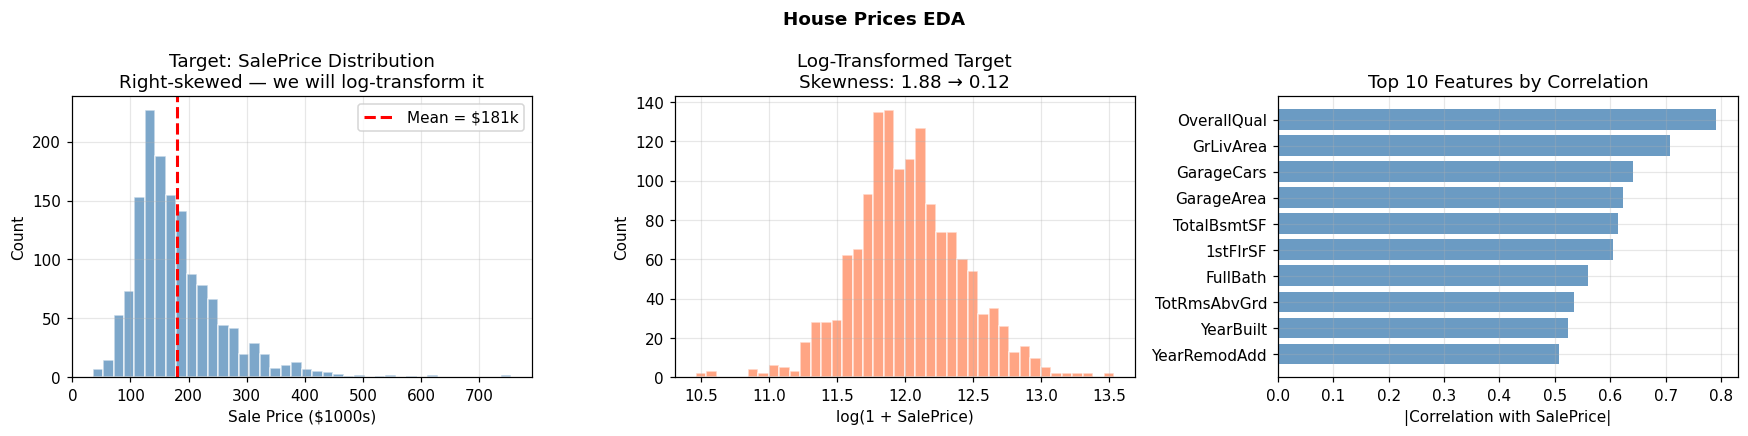

Top correlated features:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [49]:
# ── Quick EDA before modeling ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
axes[0].hist(df['SalePrice'] / 1000, bins=40,
            color='steelblue', alpha=0.7, edgecolor='white')
axes[0].axvline(df['SalePrice'].mean() / 1000, color='red', ls='--', lw=2,
                label=f"Mean = ${df['SalePrice'].mean()/1000:.0f}k")
axes[0].set_xlabel('Sale Price ($1000s)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target: SalePrice Distribution\nRight-skewed — we will log-transform it')
axes[0].legend()

# Log-transformed (much more Gaussian — better for linear models)
log_price = np.log1p(df['SalePrice'])
log_price = pd.Series(log_price)

axes[1].hist(log_price, bins=40, color='coral', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('log(1 + SalePrice)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Log-Transformed Target\n'
                  f'Skewness: {df["SalePrice"].skew():.2f} → {log_price.skew():.2f}')

# Top correlated features with SalePrice
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)
top10 = corr.head(10)
axes[2].barh(top10.index[::-1], top10.values[::-1], color='steelblue', alpha=0.8)
axes[2].set_xlabel('|Correlation with SalePrice|')
axes[2].set_title('Top 10 Features by Correlation')

plt.suptitle('House Prices EDA', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Top correlated features:\n{top10.to_string()}")


In [50]:
# ── Preprocessing pipeline ───────────────────────────────────────────────────

# 1. Use the top numerical features (avoids encoding categorical for now)
num_features = [
    'GrLivArea', 'OverallQual', 'GarageCars', 'GarageArea',
    'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd',
    'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'Fireplaces',
    'BsmtFinSF1', 'LotFrontage', 'WoodDeckSF', 'OpenPorchSF',
    '2ndFlrSF', 'HalfBath', 'LotArea', 'BsmtFullBath',
    'BsmtUnfSF', 'BedroomAbvGr', 'KitchenAbvGr', 'EnclosedPorch',
    'ScreenPorch', 'PoolArea', 'MiscVal', 'LowQualFinSF',
    'BsmtFinSF2', 'BsmtHalfBath', 'OverallCond', 'MoSold',
]

# Filter to columns that exist in the dataset
num_features = [c for c in num_features if c in df.columns]
print(f"Using {len(num_features)} numerical features")

# 2. Fill missing values with median
df_num = df[num_features].copy()
for col in df_num.columns:
    df_num[col] = df_num[col].fillna(df_num[col].median())

# 3. Log-transform the target
X_hp = df_num.values
y_hp = np.log1p(df['SalePrice'].values)  # predict log(price), convert back at the end

# 4. Train/test split
X_tr_hp, X_te_hp, y_tr_hp, y_te_hp = train_test_split(
    X_hp, y_hp, test_size=0.2, random_state=42)

print(f"Train: {X_tr_hp.shape}  |  Test: {X_te_hp.shape}")
print("Target: log(1+SalePrice) — we'll convert predictions back to dollars at the end")


Using 32 numerical features
Train: (1168, 32)  |  Test: (292, 32)
Target: log(1+SalePrice) — we'll convert predictions back to dollars at the end


In [51]:
# ── Train all models with proper scaling pipeline ────────────────────────────

lam_grid = np.logspace(-3, 4, 80)

models_hp = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression()),
    ]),
    'Ridge (CV)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RidgeCV(alphas=lam_grid, cv=5)),
    ]),
    'Lasso (CV)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LassoCV(alphas=lam_grid, cv=5, max_iter=10000)),
    ]),
    'ElasticNet (CV)': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
                                cv=5, max_iter=10000)),
    ]),
}

print("=" * 75)
print("  House Prices: Model Comparison")
print("=" * 75)
print(f"  {'Model':>22}  {'Train R²':>10}  {'Test R²':>9}  {'RMSE(log)':>11}  {'~$ Error'}")
print("  " + "-" * 70)

hp_results = {}
for name, pipe in models_hp.items():
    pipe.fit(X_tr_hp, y_tr_hp)
    y_pred_tr = pipe.predict(X_tr_hp)
    y_pred_te = pipe.predict(X_te_hp)

    r2_tr  = r2_score(y_tr_hp, y_pred_tr)
    r2_te  = r2_score(y_te_hp, y_pred_te)
    rmse_  = np.sqrt(mean_squared_error(y_te_hp, y_pred_te))

    # Convert log-RMSE to approximate dollar error
    price_error = np.expm1(rmse_) * df['SalePrice'].median() / np.expm1(np.mean(y_te_hp))
    dollar_str  = f"~${int(np.expm1(rmse_) * 100):.0f}k"

    hp_results[name] = {
        'pipe': pipe, 'r2_tr': r2_tr, 'r2_te': r2_te,
        'rmse': rmse_, 'y_pred_te': y_pred_te
    }
    flag = " ← best" if r2_te == max(r['r2_te'] for r in hp_results.values()) else ""
    print(f"  {name:>22}  {r2_tr:>10.4f}  {r2_te:>9.4f}  {rmse_:>11.4f}  {dollar_str}{flag}")


  House Prices: Model Comparison
                   Model    Train R²    Test R²    RMSE(log)  ~$ Error
  ----------------------------------------------------------------------
       Linear Regression      0.8589     0.8779       0.1510  ~$16k ← best
              Ridge (CV)      0.8544     0.8729       0.1540  ~$16k
              Lasso (CV)      0.8542     0.8701       0.1557  ~$16k
         ElasticNet (CV)      0.8530     0.8684       0.1567  ~$16k


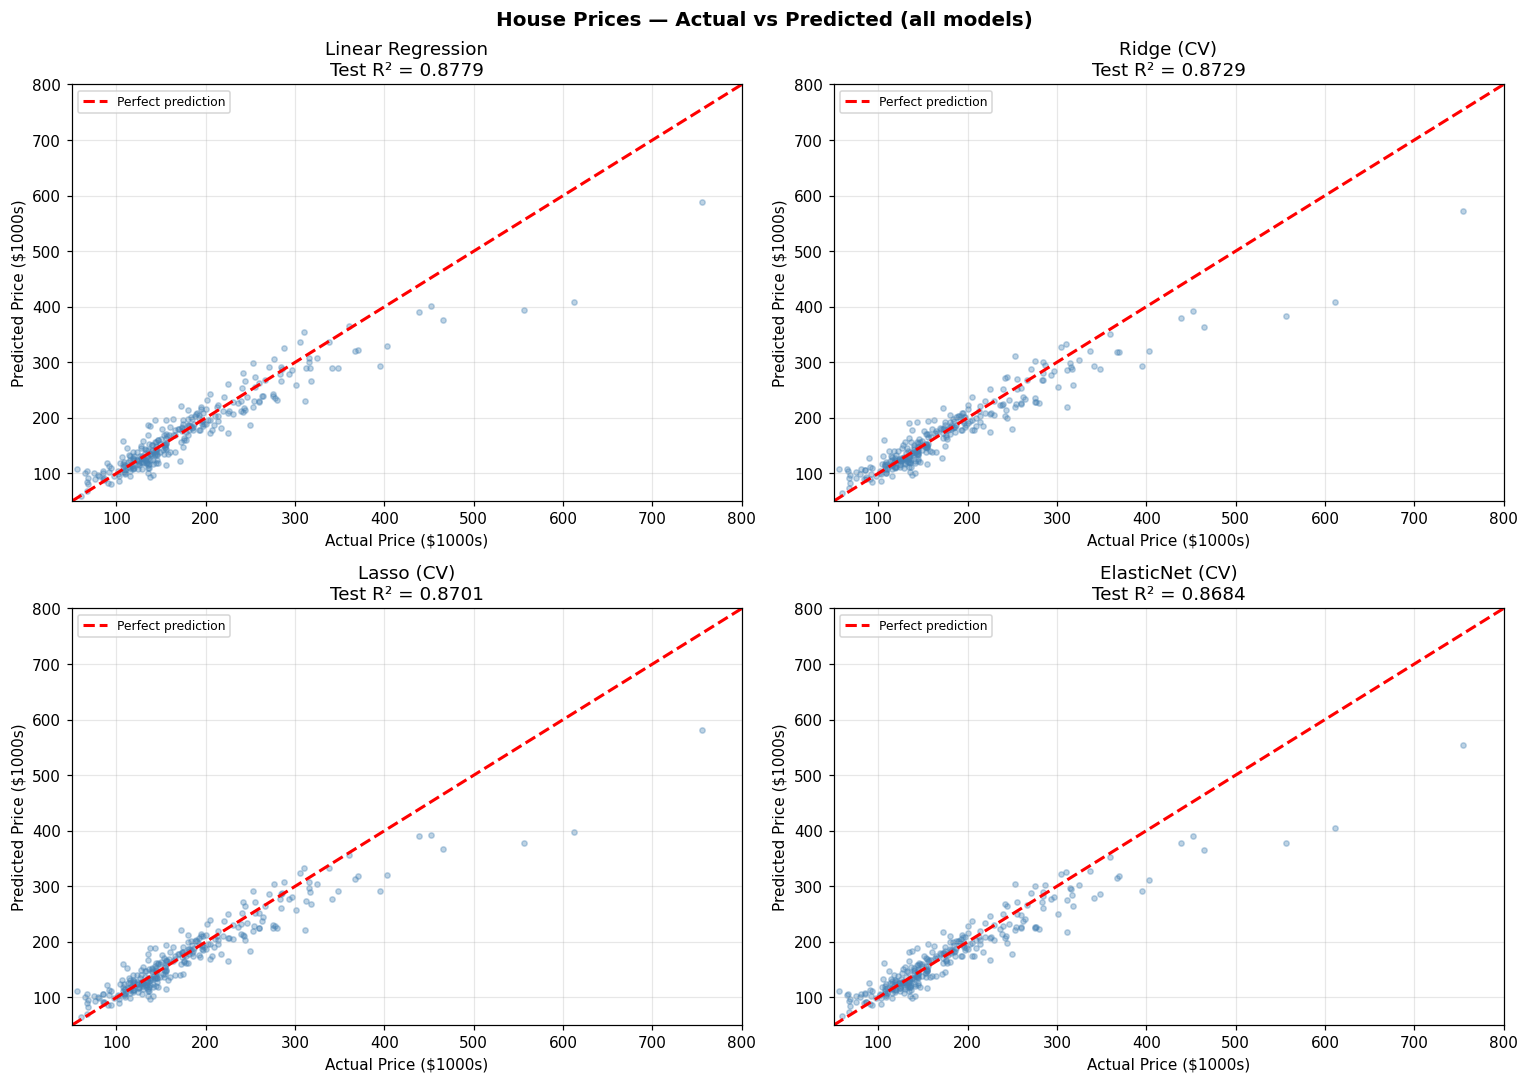

In [52]:
# ── Visualize results ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

model_list = list(hp_results.items())
for ax, (name, res) in zip(axes.flat, model_list):
    # Convert back to dollar scale for the plot
    y_pred_dollars  = np.expm1(res['y_pred_te'])
    y_true_dollars  = np.expm1(y_te_hp)

    ax.scatter(y_true_dollars / 1000, y_pred_dollars / 1000,
              alpha=0.35, s=12, color='steelblue')
    lim = [50, 800]
    ax.plot(lim, lim, 'r--', lw=2, label='Perfect prediction')
    ax.set_xlabel('Actual Price ($1000s)')
    ax.set_ylabel('Predicted Price ($1000s)')
    ax.set_title(f'{name}\nTest R² = {res["r2_te"]:.4f}')
    ax.legend(fontsize=8)
    ax.set_xlim(lim)
    ax.set_ylim(lim)

plt.suptitle('House Prices — Actual vs Predicted (all models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


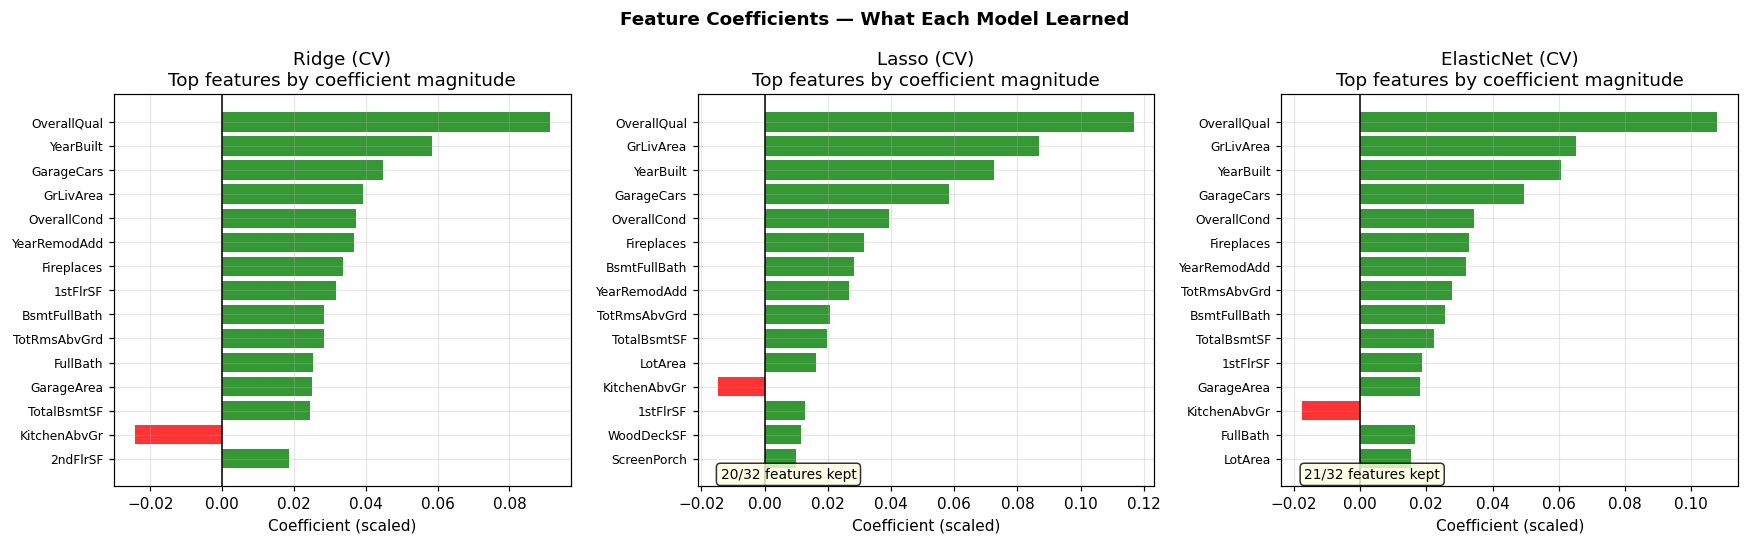

  Final Summary
  Linear Regression       R²=0.8779  features used=32/32  λ=N/A
  Ridge (CV)              R²=0.8729  features used=32/32  λ=207.23146452190295
  Lasso (CV)              R²=0.8701  features used=20/32  λ=0.007692649574879146
  ElasticNet (CV)         R²=0.8684  features used=21/32  λ=0.07287381445479407


In [53]:
# ── Which features does each model emphasize? ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

model_names_sub = ['Ridge (CV)', 'Lasso (CV)', 'ElasticNet (CV)']
colors_sub      = ['steelblue', 'coral', 'purple']

for ax, mname, color in zip(axes, model_names_sub, colors_sub):
    pipe = hp_results[mname]['pipe']
    coef = pipe.named_steps['model'].coef_

    # Sort by absolute magnitude
    order  = np.argsort(np.abs(coef))[::-1]
    top_n  = min(15, len(num_features))
    top_names = [num_features[i] for i in order[:top_n]]
    top_coef  = coef[order[:top_n]]

    colors_bar = ['green' if c > 0 else 'red' for c in top_coef]
    ax.barh(range(top_n), top_coef[::-1],
            color=colors_bar[::-1], alpha=0.8)
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_names[::-1], fontsize=8)
    ax.axvline(0, color='k', lw=1)
    ax.set_title(f'{mname}\nTop features by coefficient magnitude')
    ax.set_xlabel('Coefficient (scaled)')

    # For Lasso: show how many are zeroed out
    if 'Lasso' in mname or 'Elastic' in mname:
        nz = np.sum(coef != 0)
        ax.text(0.05, 0.02, f'{nz}/{len(coef)} features kept',
                transform=ax.transAxes, fontsize=9,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Feature Coefficients — What Each Model Learned', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Final summary
print("=" * 55)
print("  Final Summary")
print("=" * 55)
for name, res in hp_results.items():
    r2_te  = res['r2_te']
    n_feat = np.sum(res['pipe'].named_steps['model'].coef_ != 0)
    best_lambda = getattr(res['pipe'].named_steps['model'], 'alpha_', 'N/A')
    print(f"  {name:<22}  R²={r2_te:.4f}  features used={n_feat}/{len(num_features)}  λ={best_lambda}")


---
## Summary — What to Remember as an ML Engineer

### The Core Idea
Regularization = add a penalty to the loss function to prevent overfitting.

### The Three Options

| | Ridge | Lasso | ElasticNet |
|---|---|---|---|
| **Penalty** | `λ Σ w²` | `λ Σ \|w\|` | Mix of both |
| **Creates zeros?** | No | Yes | Some |
| **Feature selection?** | No | Yes | Partial |
| **Best when** | Most features matter | Many useless features | Unsure |
| **sklearn** | `RidgeCV(alphas=...)` | `LassoCV(...)` | `ElasticNetCV(...)` |

### The Workflow (Copy This Every Time)

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import numpy as np

# 1. Build pipeline (always scale before regularization)
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)),
])

# 2. Train
pipe.fit(X_train, y_train)

# 3. Best λ (chosen automatically)
print(pipe.named_steps['model'].alpha_)

# 4. Predict & evaluate
y_pred = pipe.predict(X_test)
```

### When Do We Actually Need This?
- We have more features than samples → **always regularize**
- train R² >> test R² → **we're overfitting → regularize**
- Features are correlated → **Ridge first, ElasticNet if Ridge isn't enough**
- We want to know which features matter → **Lasso**

### What's Next
- `polynomial_regression.ipynb` — non-linear patterns + regularization together
- `decision_trees.ipynb` — tree-based regularization (max_depth, min_samples)
